# Project Title: Patient Readmission Risk Model Evaluation


### Short Description
The model predicts whether a patient is high-risk or low-risk.

### Key Points
- Actual Positive: patient is truly high-risk
- Actual Negative: patient is truly low-risk
- Predicted Positive: model predicts high-risk
- Predicted Negative: model predicts low-risk


In [1]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# create n= 100 patient records
np.random.seed(42)
n = 100

# patient features
patient_id = np.arange(1, n + 1)
age = np.random.randint(25, 76, n)
glucose = np.round(np.random.normal(110, 25, n), 1)
bmi = np.round(np.random.normal(27, 5, n), 1)

# actual label: 1 = high risk, 0 = low risk
score = (glucose - 110) / 20 + (age - 50) / 25 + (bmi - 27) / 10 - 0.4
prob_actual = 1 / (1 + np.exp(-score))
actual = (prob_actual > 0.5).astype(int)

# predicted label: model prediction with small error
noise = np.random.normal(0, 0.18, n)
prob_pred = prob_actual + noise
predicted = (prob_pred > 0.5).astype(int)

# create dataframe
df = pd.DataFrame({
    'Patient_ID': patient_id,
    'Age': age,
    'Glucose': glucose,
    'BMI': bmi,
    'Actual_Positive': actual,
    'Predicted_Positive': predicted
})

# save csv file
df.to_csv('patient_predictions.csv', index=False)

# check row count
print(df.shape)

# show first rows
df.head()

(100, 6)


,Patient_ID,Age,Glucose,BMI,Actual_Positive,Predicted_Positive
0,1,63,108.9,22.8,0,1
1,2,53,103.1,30.4,0,0
2,3,39,70.9,36.4,0,0
3,4,67,90.1,29.0,0,0
4,5,32,133.3,23.9,0,0


### Dataset
- Features: Age, Glucose, BMI
- Actual_Positive: true patient risk
- Predicted_Positive: model prediction

In [2]:
# load csv file
df = pd.read_csv('patient_predictions.csv')

# check data
df.head(10)

,Patient_ID,Age,Glucose,BMI,Actual_Positive,Predicted_Positive
0,1,63,108.9,22.8,0,1
1,2,53,103.1,30.4,0,0
2,3,39,70.9,36.4,0,0
3,4,67,90.1,29.0,0,0
4,5,32,133.3,23.9,0,0
5,6,45,126.9,24.4,0,1
6,7,63,127.5,27.1,1,1
7,8,43,114.3,28.9,0,0
8,9,47,126.6,27.3,1,1
9,10,35,116.0,29.5,0,0


### Confusion Matrix Parts

- True Positive, TP: actual positive, predicted positive
- False Positive, FP: actual negative, predicted positive
- False Negative, FN: actual positive, predicted negative
- True Negative, TN: actual negative, predicted negative

In [3]:
# convert to boolean
actual = df['Actual_Positive'] == 1
pred = df['Predicted_Positive'] == 1

# confusion matrix values
TP = int((actual & pred).sum())
FP = int((~actual & pred).sum())
FN = int((actual & ~pred).sum())
TN = int((~actual & ~pred).sum())

# show values
print('True Positive:', TP)
print('False Positive:', FP)
print('False Negative:', FN)
print('True Negative:', TN)


True Positive: 31
False Positive: 7
False Negative: 9
True Negative: 53


### Short Metric Meaning

- Accuracy-----------------------Overall correct predictions
- Precision-----------------------Positive predictions that are correct
- Recall--------------------------Actual positives correctly found
- F1-Score-----------------------Balance of precision and recall
- Specificity----------------------Actual negatives correctly found
- Type 1 Error Rate--------------False Positive rate
- Type 2 Error Rate--------------False Negative rate

In [4]:
# total patients
total = TP + FP + FN + TN

# evaluation metrics
accuracy = (TP + TN) / total

precision = TP / (TP + FP) if (TP + FP) > 0 else 0

recall = TP / (TP + FN) if (TP + FN) > 0 else 0

f1 = 2 * precision * recall / \
    (precision + recall) if (precision + recall) > 0 else 0
# In f1 using /(division) and \ (backslash) to break up long formulas or lines of code

specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

# type 1 error = false positive rate
type1_error_rate = FP / (FP + TN) if (FP + TN) > 0 else 0

# type 2 error = false negative rate
type2_error_rate = FN / (FN + TP) if (FN + TP) > 0 else 0

# metrics table
metrics = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'Specificity',
        'Type 1 Error Rate',
        'Type 2 Error Rate'
    ],
    'Value': [
        accuracy,
        precision,
        recall,
        f1,
        specificity,
        type1_error_rate,
        type2_error_rate
    ]
})

# show metrics
metrics

,Metric,Value
0,Accuracy,0.840000
1,Precision,0.815789
2,Recall,0.775000
3,F1-Score,0.794872
4,Specificity,0.883333
5,Type 1 Error Rate,0.116667
6,Type 2 Error Rate,0.225000


### Confusion Matrix Table

Rows = Actual values  
Columns = Predicted values

In [5]:
# create confusion matrix dataframe
cm = pd.DataFrame(
    [[TN, FP],
     [FN, TP]],
    index=['Actual Negative', 'Actual Positive'],
    columns=['Predicted Negative', 'Predicted Positive']
)

# show confusion matrix
cm

,Predicted Negative,Predicted Positive
Actual Negative,53,7
Actual Positive,9,31


### Visualization

- Heatmap for confusion matrix
- Bar chart for evaluation metrics

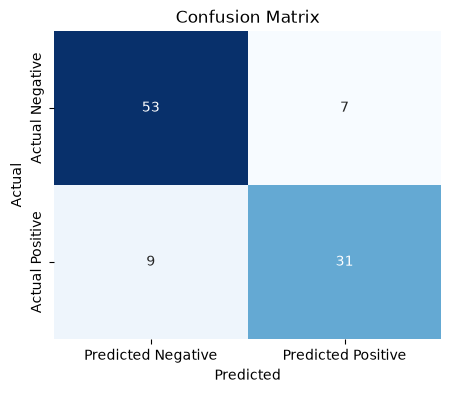

In [6]:
# draw confusion matrix heatmap
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_13028\1521097950.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


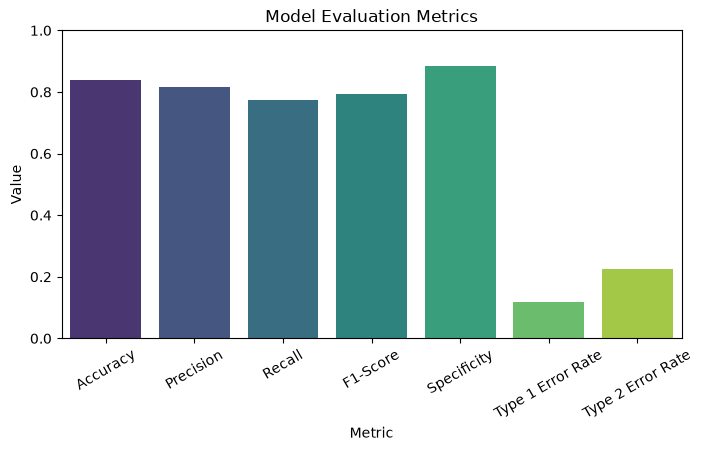

In [7]:
# draw metrics bar chart
plt.figure(figsize=(8, 4))

sns.barplot(
    x=metrics['Metric'],
    y=metrics['Value'],
    palette='viridis'
)

plt.ylim(0, 1)
plt.title('Model Evaluation Metrics')
plt.xlabel('Metric')
plt.ylabel('Value')
plt.xticks(rotation=30)

plt.show()